In [ ]:
#Notes for Tiffany
#Write function that takes in a data point e.g. (city_name, {events: [...], params: ...}) and outputs a number between 0 and 1
#sum of numbers should be about 400

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

with open('data/county_data.pkl', 'rb') as f:
    city_data = pickle.load(f)
def hasna(p):
    return any(np.isnan(x) for x in p)
city_data = {k: v for k, v in city_data.items() if not hasna(v['params'])}
city_data_l = list(city_data.items())

In [15]:
#Get first element of city data with  len of events > 0
event_l = [x for x in city_data_l if len(x[1]['events']) > 0]
#set max default to zero for empty list case
event_severity = []
for c in city_data_l:
    if len(c[1]['events']) > 0:
        events = c[1]['events']
        max_severity = max([e[1] for e in events])
        event_severity.append(max_severity)
    else:
        event_severity.append(0)
event_severity = np.array(event_severity)

In [3]:
#TODO 
#1. Update the combined sample probabilities to use population, population density, and gun density DONE
#2. Subsample the data based on the combined sample probabilities
#3. Make scatter plots of all of those things compared to each other for both the subsampled and full data to check that they look okay
#4. Check the probabilities of the subsampled data to make sure they are still reasonable (nothing that's like 1 in a billion or something)
#5. Update everything to use random seeds for reproducibility
#6. Comment out the code in city_data.py that generates the data so that it doesn't run every time and save all this stuff in a pickle file

In [4]:
#original andrew population weighting code


# population_vals = np.array([e['params'][0] for e in city_data.values()])
# # need to make x_select prob.sum about 400 so scale the population 
# def softmax(x):
#     return np.exp(x) / (1 + np.exp(x))
# population_weighting = lambda x: 2*(softmax(x/1e5) - 0.5)
# population_weights = [population_weighting(x) for x in population_vals]



# def prob_select(city_data):
#     if(len(city_data['events']) > 0):
#         return 1
#     return population_weighting(city_data['params'][0])

# target_dataset_size = 450
# scale_factor = (target_dataset_size - num_event) / sum_no_event
# sample_probs = population_weighting * scale_factor
# sample_probs[had_event] = 1.0

# x_select_prob = np.array([prob_select(city_data) for _, city_data in city_data_l])
# subsampled_mask = np.random.uniform(0, 1, x_select_prob.shape) < x_select_prob
# subsampled_populations = population_vals[subsampled_mask]
# x_select_prob.sum(), subsampled_mask.sum(), np.max(1/x_select_prob[subsampled_mask])

In [24]:
import random
import numpy as np  
random.seed(42)
np.random.seed(42)

def softmax(x):
    return np.exp(x) / (1 + np.exp(x))

In [ ]:
population_vals = np.array([e[1]['params'][0] for e in city_data_l])


p_weighting = lambda x: 2*(softmax(((x/1e6)))-0.5)
p_weights = np.array([p_weighting(x) for x in population_vals])

had_event = np.array([len(city_data['events']) > 0 for _, city_data in city_data_l])
sum_no_event = p_weights[~had_event].sum()
num_event = had_event.sum()

target_dataset_size = 450
scale_factor = (target_dataset_size - num_event) / sum_no_event
p_sample_probs = p_weights * scale_factor
p_sample_probs[had_event] = 1.0  # Ensure cities with events are always selected

print(f"Scale factor: {scale_factor}, Total sample probability: {p_sample_probs.sum()}")
print(p_sample_probs.sum())
print(p_sample_probs.max())


Scale factor: 2.4662932201523224, Total sample probability: 450.00000000000006
450.00000000000006
2.466293187473955


In [18]:
population_dens_vals = np.array([e[1]['params'][1] for e in city_data_l])

def softmax(x):
    return np.exp(x) / (1 + np.exp(x))

pdens_weighting = lambda x: 2*(softmax(((x/3e5)))-0.5)
pdens_weights = np.array([pdens_weighting(x) for x in population_dens_vals])

had_event = np.array([len(city_data['events']) > 0 for _, city_data in city_data_l])
sum_no_event = pdens_weights[~had_event].sum()
num_event = had_event.sum()

target_dataset_size = 450
scale_factor = (target_dataset_size - num_event) / sum_no_event
pden_sample_probs = pdens_weights * scale_factor
pden_sample_probs[had_event] = 1.0  # Ensure cities with events are always selected

print(f"Scale factor: {scale_factor}, Total sample probability: {pden_sample_probs.sum()}")
print(pden_sample_probs.sum())
print(pden_sample_probs.max())


Scale factor: 13.933969067163297, Total sample probability: 450.0
450.0
1.0


In [19]:
gun_dens_vals = np.array([e[1]['params'][2] for e in city_data_l])

def softmax(x): 
    return np.exp(x) / (2 + np.exp(x)) #some sort of normalization function, takes in number and outputs a number between 0 and 1, really nice

gdens_weighting = lambda x: 2*(softmax(((x/1e3)))-0.5) #adjust for gun density
gdens_weights = np.array([gdens_weighting(x) for x in gun_dens_vals])

had_event = np.array([len(city_data['events']) > 0 for _, city_data in city_data_l])
sum_no_event = gdens_weights[~had_event].sum()
num_event = had_event.sum()

target_dataset_size = 450
scale_factor = (target_dataset_size - num_event) / sum_no_event
gun_sample_probs = gdens_weights * scale_factor
gun_sample_probs[had_event] = 1.0  # Ensure cities with events are always selected
gun_sample_probs = np.clip(gun_sample_probs, 0, 1)  # Ensure probabilities are between 0 and 1

print(f"Scale factor: {scale_factor}, Total sample probability: {gun_sample_probs.sum()}")
print(gun_sample_probs.sum())
print(gun_sample_probs.max())

#add all three sample probability together and divide by 3
combined_sample_probs = (p_sample_probs + gun_sample_probs + gun_sample_probs)/3

print(f"Combined sample probabilities sum: {combined_sample_probs.sum()}")

Scale factor: -0.03728404842768744, Total sample probability: 449.99999999999994
449.99999999999994
1.0
Combined sample probabilities sum: 450.0


In [ ]:
#4. Check the probabilities of the subsampled data to make sure they are still reasonable (nothing that's like 1 in a billion or something)
min(pden_sample_probs), min(gun_sample_probs), min(p_sample_probs), min(combined_sample_probs)

(np.float64(2.5545609956942793e-05),
 np.float64(0.0028864698848759087),
 np.float64(0.0001245478075118852),
 np.float64(0.0046410560322564))

In [ ]:
#5. Update everything to use random seeds for reproducibility 

In [ ]:
#6. Comment out the code in city_data.py that generates the data so that it doesn't run every time and save all this stuff in a pickle file

with open('data/city_data_sample_probs.pkl', 'wb') as f:
    pickle.dump({
        'p_sample_probs': p_sample_probs,
        'gun_sample_probs': gun_sample_probs,
        'pden_sample_probs': pden_sample_probs,
        'combined_sample_probs': combined_sample_probs
    }, f)
    print("Sample probabilities saved to 'data/city_data_sample_probs.pkl'")     


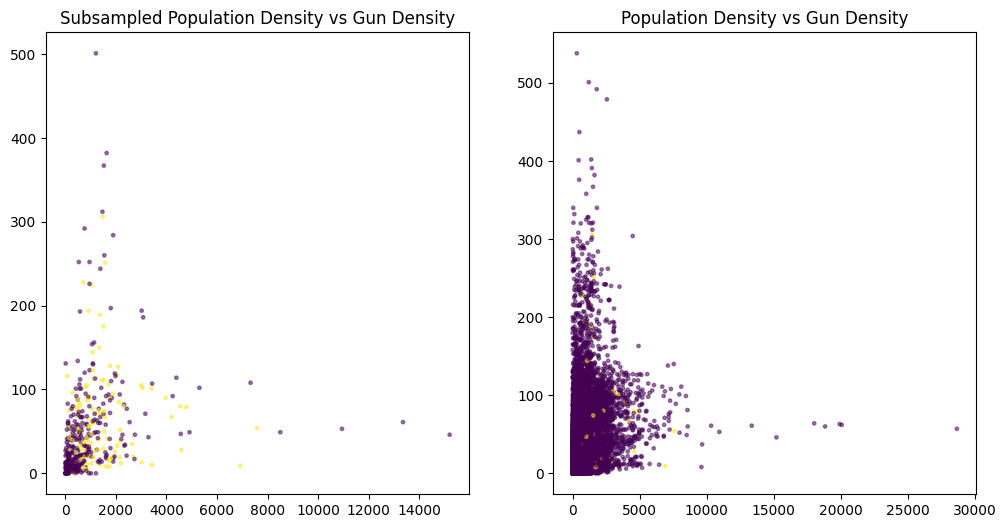

In [11]:
subsampled_mask = np.random.uniform(0, 1, combined_sample_probs.shape) < combined_sample_probs
subsampled_population_dens = population_dens_vals[subsampled_mask]
subsampled_gun_dens = gun_dens_vals[subsampled_mask]
subsampled_had_event = had_event[subsampled_mask]
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].set_title('Subsampled Population Density vs Gun Density')
ax[1].set_title('Population Density vs Gun Density')
ax[0].scatter(subsampled_population_dens, subsampled_gun_dens, alpha=0.5, c=subsampled_had_event, s=6)
ax[1].scatter(population_dens_vals, gun_dens_vals, alpha=0.5, c=had_event, s=6)

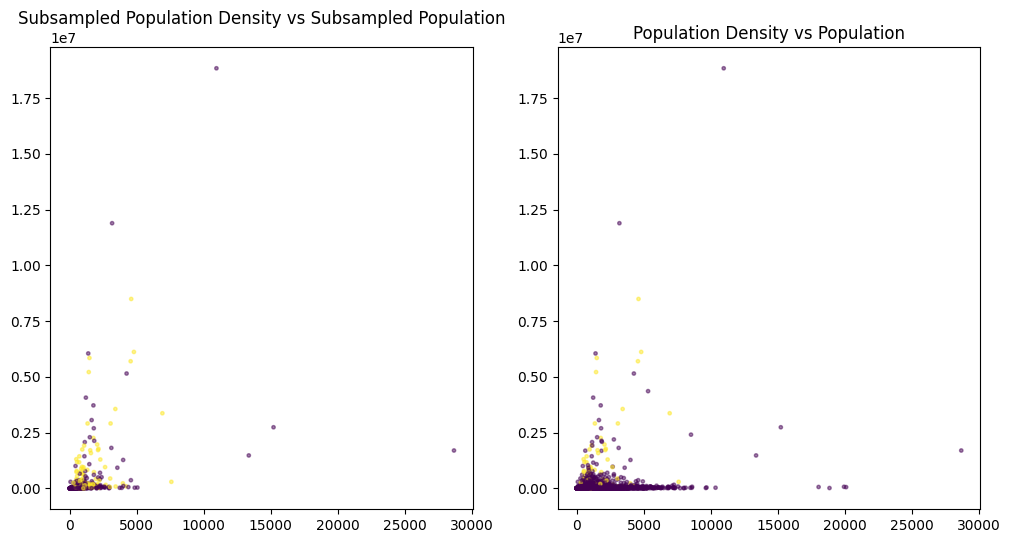

In [13]:
subsampled_mask = np.random.uniform(0, 1, combined_sample_probs.shape) < combined_sample_probs
subsampled_population_dens = population_dens_vals[subsampled_mask]
subsampled_pop = population_vals[subsampled_mask]
subsampled_had_event = had_event[subsampled_mask]
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].set_title('Subsampled Population Density vs Subsampled Population')
ax[1].set_title('Population Density vs Population')
ax[0].scatter(subsampled_population_dens, subsampled_pop, alpha=0.5, c=subsampled_had_event, s=6)
ax[1].scatter(population_dens_vals, population_vals, alpha=0.5, c=had_event, s=6)

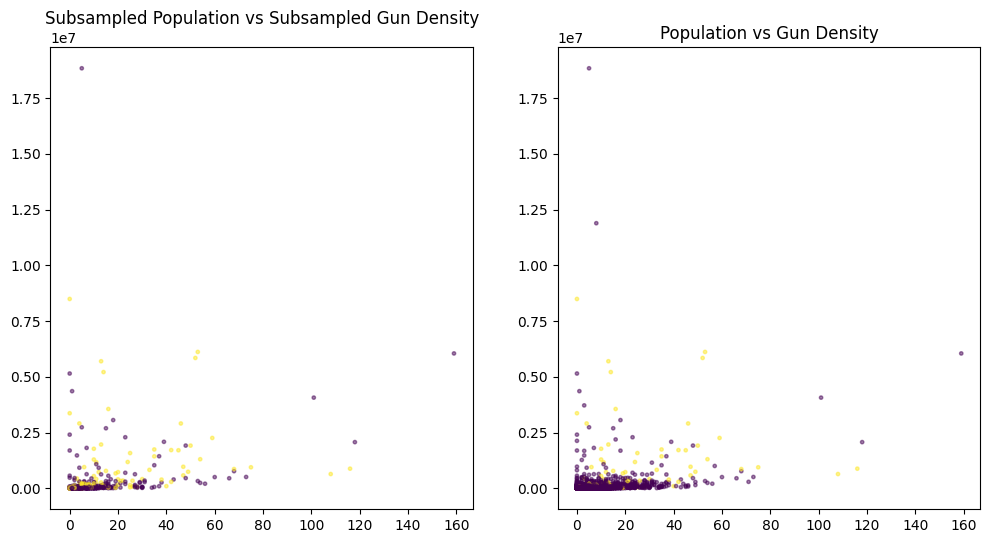

In [11]:
subsampled_mask = np.random.uniform(0, 1, combined_sample_probs.shape) < combined_sample_probs
subsampled_gun_dens = gun_dens_vals[subsampled_mask]
subsampled_pop = population_vals[subsampled_mask]
subsampled_had_event = had_event[subsampled_mask]
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].set_title('Subsampled Population vs Subsampled Gun Density')
ax[1].set_title('Population vs Gun Density')
ax[0].scatter( subsampled_gun_dens, subsampled_pop, alpha=0.5, c=subsampled_had_event, s=6)
ax[1].scatter(gun_dens_vals, population_vals, alpha=0.5, c=had_event, s=6)

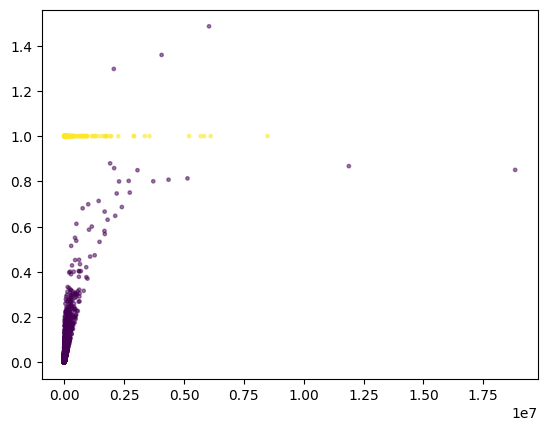

In [12]:
#plot points of the combined sample probabilities
plt.scatter(population_vals, combined_sample_probs, alpha=0.5, c=had_event, s=6)
plt.show()

In [13]:
# city_data_f = [c for c in city_data.values() if c['events']]
# city_data_base = [c for c in city_data.values() if not c['events']]
# city_data_f_names = [c for c, d in city_data.items() if d['events']]
# city_data_base_names = [c for c, d in city_data.items() if not d['events']]
# city_base_ind = np.arange(len(city_data_base))
# np.random.seed(1)
# np.random.shuffle(city_base_ind)
# subsampled_city_data_base = np.array(city_data_base)[city_base_ind[:400]]
# subsampled_city_data_base_names = np.array(city_data_base_names)[city_base_ind[:400]]
# subsampled_city_data = np.concatenate([city_data_f, subsampled_city_data_base])
# subsampled_city_data_names = np.concatenate([city_data_f_names, subsampled_city_data_base_names])
# base_weight = len(city_data_base) / 400
# subsample_weights = np.array([1+base_weight*(len(c['events']) == 0) for c in subsampled_city_data])

Text(0, 0.5, 'probability')

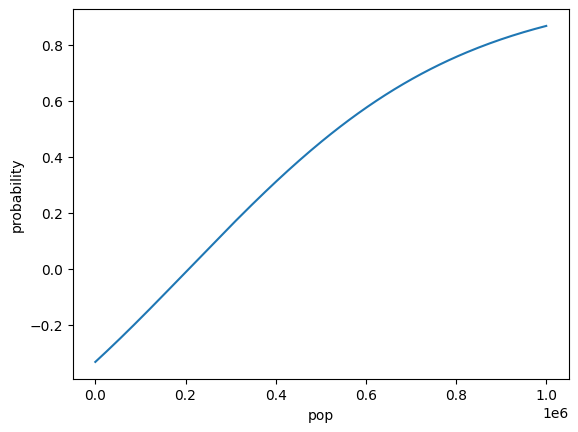

In [36]:
x = np.linspace(0, 1e6, 200)
plt.plot(x, pdens_weighting(x))
plt.xlabel('pop')
plt.ylabel('probability')

In [15]:
#andrewpoop
pdens_weights = np.array([pdens_weighting(x) for x in population_dens_vals])
had_event = np.array([len(city_data['events']) > 0 for _, city_data in city_data_l])
sum_no_event = pdens_weights[~had_event].sum()
num_event = had_event.sum()

target_dataset_size = 450
scale_factor = (target_dataset_size - num_event) / sum_no_event
sample_probs = pdens_weights * scale_factor
sample_probs[had_event] = 1.0  # Ensure cities with events are always selected
print(f"Scale factor: {scale_factor}, Total sample probability: {sample_probs.sum()}")




Scale factor: 13.955511991591713, Total sample probability: 450.0


In [16]:
#tiffanyawesome
raw_probs = np.array([
    1.0 if len(city_data['events']) > 0 else pdens_weighting(city_data['params'][1])
    for _, city_data in city_data_l
])

print(raw_probs.sum())


144.5749143562934


In [17]:
#andrewpoop
def prob_select(city_data):
    if len(city_data['events']) > 0:
        return 1.0
    prob = pdens_weighting(city_data['params'][1])
    return min(1.0, prob * scale_factor)

x_select_prob = np.array([prob_select(city_data) for _, city_data in city_data_l])

for i, (_, city_data) in enumerate(city_data_l):
    if len(city_data['events']) > 0:
        x_select_prob[i] = 1.0


subsampled_mask = np.random.uniform(0, 1, x_select_prob.shape) < x_select_prob
subsampled_populations = population_dens_vals[subsampled_mask]

(1 / x_select_prob[subsampled_mask]), scale_factor

x_select_prob.sum(), subsampled_mask.sum(), np.max

(np.float64(450.0), np.int64(442), <function max at 0x72c8c4ec9db0>)

In [18]:
#andrewpoop
had_event = np.array([len(city_data['events']) > 0 for _, city_data in city_data_l])
raw_probs[~had_event].sum()

np.float64(23.574914356293387)

In [19]:

# #scale_factor = max(1.0, 400 / raw_probs.sum())

# #def prob_select(city_data):
#     #if len(city_data['events']) > 0:
#         return 1.0
#     prob = pdens_weighting(city_data['params'][1])
#     return min(1.0, prob * scale_factor)

# #x_select_prob = np.array([prob_select(city_data) for _, city_data in city_data_l])

# #scale_factor = 300/raw_probs.sum()


# #for i, (_, city_data) in enumerate(city_data_l):
#     if len(city_data['events']) > 0:
#         x_select_prob[i] = 1.0


# #x_select_prob = np.minimum(raw_probs * scale_factor, 1.0)


# #subsampled_mask = np.random.uniform(0, 1, x_select_prob.shape) < x_select_prob
# #subsampled_populations = population_dens_vals[subsampled_mask]


# #x_select_prob.sum(), subsampled_mask.sum(), np.max(1 / x_select_prob[subsampled_mask]), scale_factor


In [20]:
import matplotlib.pyplot as plt
population_densities = np.array([c['params'][1] for c in city_data.values()])
plt.hist(population_densities, weights=population_densities, bins=np.linspace(0, 1e4, 20), alpha=0.5, label='Populations Density')
plt.show()

TypeError: list indices must be integers or slices, not str

In [ ]:
city_data['Barboursville, Virginia']['params']

CityParams(population=747, population_density=128.8, arm_count=1.0, arm_density=0.17242302543507365)

In [ ]:
import matplotlib.pyplot as plt
plt.hist([len(c['events']) for c in city_data_base + city_data_f], bins=20, alpha=0.5, label='With Events')
plt.show()

NameError: name 'city_data_base' is not defined